![Retrieval-Augmented Generation Design Pattern@150x-100.webp](<attachment:Retrieval-Augmented Generation Design Pattern@150x-100.webp>)
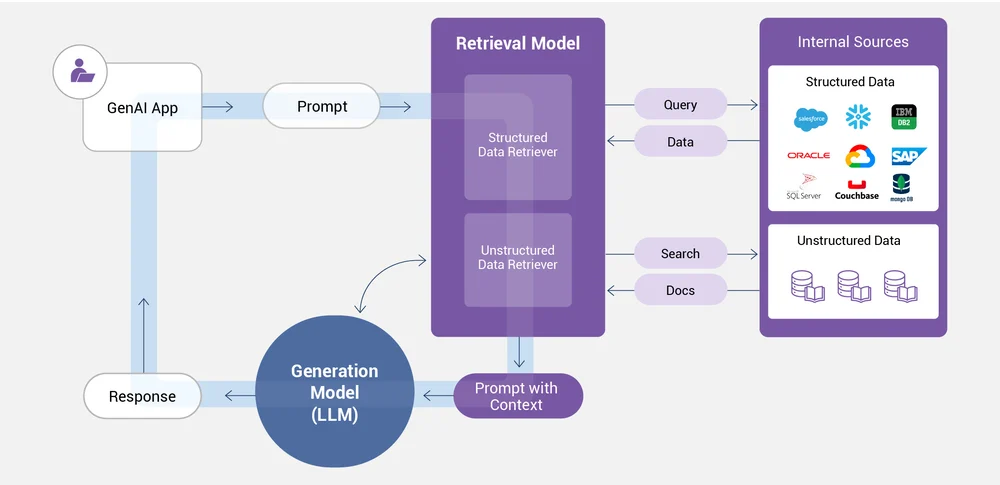

In [6]:
#Data Ingestion
from langchain_community.document_loaders import TextLoader
loader = TextLoader('file.txt')
text_documents = loader.load()
text_documents

[Document(metadata={'source': 'file.txt'}, page_content='As a Machine Learning Intern, I developed an American Sign Language (ASL) detection system using Convolutional Neural Networks (CNN).\nMy responsibilities included collecting and preprocessing gesture image data, building and training deep learning models, optimizing performance using techniques like data augmentation and dropout, and evaluating model accuracy.\nI also gained hands-on experience in deploying computer vision models for real-world gesture recognition tasks.\n\nMachine learning intern at Unified Mentor with hands-on experience in LLMs, including fine-tuning and deploying NLP models. \nSkilled in Python, PyTorch, and Transformers. Passionate about building real-world AI solutions with a focus on performance and usability.')]

In [7]:
import os
from dotenv import load_dotenv
os.environ['OPENAI_API_KEY'] = os.getenv('OPENROUTER_API_KEY')
print(os.environ['OPENAI_API_KEY'])
# Set up OpenRouter endpoint
openrouter_endpoint = "https://openrouter.ai/api/v1"
os.environ['OPENAI_API_KEY'] = os.getenv('OPENROUTER_API_KEY')
#Langsmith Tracking
os.environ['LANGCHAIN_TRACING_V1'] = 'true'  #automatically tracing the code that we're gonna write
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

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


In [8]:
#web based loader
from langchain_community.document_loaders import WebBaseLoader
import bs4

#load, chunk and index the content of the html page
loader = WebBaseLoader(web_path=("https://github.com/Iconic-Aman/Fine-Tuning-Mistral/blob/master/README.md",), )
web_documents = loader.load()
web_documents

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://github.com/Iconic-Aman/Fine-Tuning-Mistral/blob/master/README.md', 'title': 'Fine-Tuning-Mistral/README.md at master · Iconic-Aman/Fine-Tuning-Mistral · GitHub', 'description': 'Fine-tuning of Mistral using QLoRA  based on Samsum dataset  - Fine-Tuning-Mistral/README.md at master · Iconic-Aman/Fine-Tuning-Mistral', 'language': 'en'}, page_content='\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nFine-Tuning-Mistral/README.md at master · Iconic-Aman/Fine-Tuning-Mistral · GitHub\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSkip to content\n\n\n\n\n\n\n\n\n\n\n\n\n\nNavigation Menu\n\nToggle navigation\n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n            Sign in\n          \n\n\n\n\n\n\n\n\n        Product\n        \n\n\n\n\n\n\n\n\n\n\n\n\n\nGitHub Copilot\n        Write better code with AI\n      \n

In [9]:
#PDF reader
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader('attention.pdf')
pdf_documents = loader.load()

#### Text splitter

In [10]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap = 200)
documents = text_splitter.split_documents(pdf_documents)
print(len(documents))
documents[40]

43


Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On E

#### Vector Embedding Techniques
- convert text into vector
- <b>embedding </b> refers to the process of converting text into numerical vectors so it can be stored, searched, and compared in a vector database.

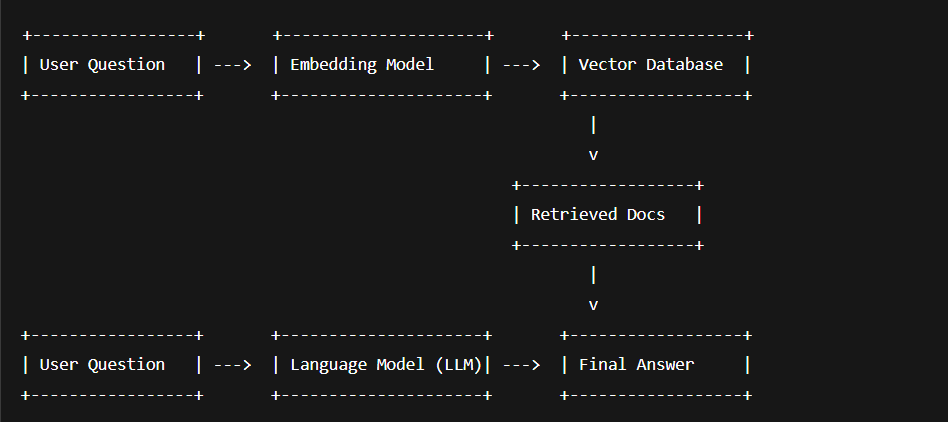

### We are going to use sentence-transformers for embedding. 
- Here're the reasons why did i not chhose OllamaEmbedding or OpenAIEmbedding
- <b>Problem with OpenAIEmbedding: </b> The embedding model is not supported by Openrouter, but you can pay for openAI embedding models.
- <b>Problem with OllamaEmbedding: </b> It's taking so much time because it is not optimized for embeddings

 Sentence-transfers model is good for vector embedding and retrieval tasks. Either we can directly use it by creating a SimpleEmbedding class or we can take this from huggingface and use it .
 <p> 
 Here we are using <b>all-MiniLM-L6-v2 </b> model.

In [11]:
from sentence_transformers import SentenceTransformer
sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(embeddings)


[[ 6.76569641e-02  6.34958968e-02  4.87131327e-02  7.93049932e-02
   3.74479853e-02  2.65277526e-03  3.93749401e-02 -7.09840422e-03
   5.93614280e-02  3.15369591e-02  6.00980893e-02 -5.29051833e-02
   4.06068265e-02 -2.59308796e-02  2.98428163e-02  1.12684851e-03
   7.35149309e-02 -5.03819138e-02 -1.22386634e-01  2.37028524e-02
   2.97265034e-02  4.24768254e-02  2.56337989e-02  1.99519284e-03
  -5.69191016e-02 -2.71598455e-02 -3.29035446e-02  6.60248697e-02
   1.19007058e-01 -4.58790585e-02 -7.26214871e-02 -3.25839929e-02
   5.23413904e-02  4.50552516e-02  8.25305562e-03  3.67023498e-02
  -1.39415562e-02  6.53919354e-02 -2.64272839e-02  2.06388984e-04
  -1.36643872e-02 -3.62809822e-02 -1.95043311e-02 -2.89738625e-02
   3.94270457e-02 -8.84090886e-02  2.62431079e-03  1.36714112e-02
   4.83063310e-02 -3.11565101e-02 -1.17329173e-01 -5.11690043e-02
  -8.85288417e-02 -2.18962971e-02  1.42986458e-02  4.44168039e-02
  -1.34814847e-02  7.43392557e-02  2.66382769e-02 -1.98762212e-02
   1.79190

In [15]:
from langchain_community.vectorstores import FAISS   #provided by langchain itself
# Define a minimal embedding-like object using a lambda
class SimpleEmbedding:
    def __init__(self, model):
        self.model = model

    def embed_documents(self, texts):
        return self.model.encode(texts, convert_to_numpy=True).tolist()

    def embed_query(self, text):
        return self.model.encode(text, convert_to_numpy=True).tolist()
    
    def __call__(self, text):
        return self.embed_query(text)  # this is what FAISS needs

# Use existing SentenceTransformer model
embedding = SimpleEmbedding(model)

# Use with FAISS
db = FAISS.from_documents(documents=documents[:10], embedding=embedding)


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [13]:
!pip install sentence-transformers

#### Retreive information from Vector Database

In [21]:
query = "Self-attention, sometimes called intra-attention"
result = db.similarity_search(query)
for doc in result:
    print(doc.page_content)

described in section 3.2.
Self-attention, sometimes called intra-attention is an attention mechanism relating different positions
of a single sequence in order to compute a representation of the sequence. Self-attention has been
used successfully in a variety of tasks including reading comprehension, abstractive summarization,
textual entailment and learning task-independent sentence representations [4, 22, 23, 19].
End-to-end memory networks are based on a recurrent attention mechanism instead of sequence-
aligned recurrence and have been shown to perform well on simple-language question answering and
language modeling tasks [28].
To the best of our knowledge, however, the Transformer is the ﬁrst transduction model relying
entirely on self-attention to compute representations of its input and output without using sequence-
aligned RNNs or convolution. In the following sections, we will describe the Transformer, motivate
The goal of reducing sequential computation also forms the founda

### Chain and Retriever

- A <b> Retriever </b> is an interface that returns documents given an unstructured query. It retrieves most relevant data from vector database based on user query.

In [23]:
#Define llama2
from langchain_community.llms import Ollama
llm = Ollama(
    model = "llama2-uncensored",
    temperature = 0.7
)

In [29]:
#Design chat Template
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_template("""
        Answer the following, question bhsed only on the provided context.
Think step by step before providing a detailed answer.
I will tip you $1000 if the user finds the answer helpful.
<context>
{context}
</context>
Question: {input} """)

In [30]:
##Chain Introduction
#create stuff document chain

from langchain.chains.combine_documents import create_stuff_documents_chain
document_chain = create_stuff_documents_chain(llm, prompt)

In [ ]:
#define retriever
retriever = db.as_retriever()  #a vector store retriever
retriever 

VectorStoreRetriever(tags=['FAISS'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000025B823FCB90>, search_kwargs={})

In [32]:
from langchain.chains import create_retrieval_chain
retrieval_chain = create_retrieval_chain(retriever, document_chain)  #pass retriever and document_chain

In [33]:
retrieval_chain.invoke({"input": "End-to-end memory networks are based"})

{'input': 'End-to-end memory networks are based',
 'context': [Document(id='c4b1f919-103d-4c52-a1be-05a871cad5d1', metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 B